<a href="https://colab.research.google.com/github/Shr06/d2c_churn_part3_churn/blob/main/churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
#Libraries
import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (accuracy_score,precision_score,
    recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,
    precision_recall_curve,roc_curve)

In [58]:
#LOAD DATA
BASE_PATH = "/content/drive/MyDrive/d2c_churn/data/"
df = pd.read_csv(BASE_PATH + "rfm_modeling_snapshot.csv")
print("Shape:",df.shape)
df.head()

Shape: (2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [59]:
#Intial checking
print('\n Info\n',df.info())
print('\n Null values\n',df.isnull().sum().sort_values(ascending=False))
print('\n Describe\n',df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category


 The value counts of churn_next_60d
 churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

 The percentage of value counts of churn_next_60d
 churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


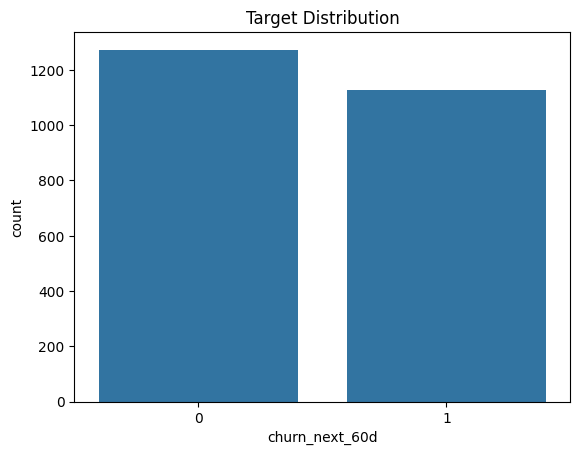

In [60]:
#Target Analysis
print('\n The value counts of churn_next_60d\n',df['churn_next_60d'].value_counts())
print('\n The percentage of value counts of churn_next_60d\n',df['churn_next_60d'].value_counts(normalize=True)*100)
#visualization
sns.countplot(data=df,x='churn_next_60d')
plt.title("Target Distribution")
plt.show()

### Leakage Prevention — Column-Level Audit

The snapshot date is **2025-09-30**. The target `churn_next_60d` covers the window
**2025-10-01 → 2025-11-29**. Every feature must come from on or before 2025-09-30.

| Column group | Example columns | Why it is safe |
|---|---|---|
| Recency | `recency_days` | Days since last order before snapshot — backward-looking |
| Frequency | `frequency_30d`, `frequency_180d` | Order counts in trailing windows ending at snapshot |
| Monetary | `monetary_180d`, `avg_order_value_180d` | Revenue sums in trailing windows ending at snapshot |
| Engagement | `sessions_30d`, `pages_per_session_30d` | Web session counts before snapshot |
| Support | `negative_ticket_rate_90d`, `tickets_90d` | Support tickets raised before snapshot |
| Returns | `return_rate_180d` | Returns processed before snapshot |
| Customer attributes | `loyalty_tier`, `acquisition_channel`, `marketing_consent` | Static profile fields set at or before snapshot |
| Discount behaviour | `avg_discount_pct_180d` | Discounts applied in trailing window before snapshot |

**Columns explicitly excluded:**
- `customer_id` — identifier, not a predictive signal
- `snapshot_date` — constant for all rows (2025-09-30), carries zero information
- `churn_next_60d` — the target itself; using it as a feature would be direct leakage
- `split` — partition label assigned after snapshot; must not be used as a feature

**Leakage check:** No column name contains the words `future`, `next`, or a date suffix
beyond the snapshot. Confirmed with:

In [61]:
#Leakage Prevention
print(df.columns.tolist())
drop_cols = ['customer_id','snapshot_date','churn_next_60d','split']
X = df.drop(columns=drop_cols)
print(f'\nAfter dropping the columns we have\n')
print(X.columns.tolist())
y = df['churn_next_60d']

['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

After dropping the columns we have

['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_ad

In [62]:
#Provided Train/Validation/Test Split
train_df = df[df['split']=='train']
val_df = df[df['split']=='validation']
test_df = df[df['split']=='test']
print(f'the shape of train {train_df.shape}')
print(f'the shape of validation {val_df.shape}')
print(f'the shape of test {test_df.shape}')

the shape of train (1728, 29)
the shape of validation (336, 29)
the shape of test (336, 29)


In [63]:
#Create X and y
feature_cols = [col for col in df.columns
    if col not in [
        'customer_id','snapshot_date',
        'churn_next_60d','split']]

X_train = train_df[feature_cols]
y_train = train_df['churn_next_60d']

X_val = val_df[feature_cols]
y_val = val_df['churn_next_60d']

X_test = test_df[feature_cols]
y_test = test_df['churn_next_60d']

In [64]:
# Leakage check
leakage_keywords = ['next', 'future', 'after', 'oct', 'nov']
risky = [c for c in X_train.columns
         if any(k in c.lower() for k in leakage_keywords)]
print("Features being used:", X_train.columns.tolist())
print("Potentially leaky columns:", risky if risky else "None found ")

Features being used: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']
Potentially leaky columns: None found 


In [65]:
#Identify Column Types
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numerical_cols))

Categorical Features: 6
Numerical Features: 19


In [66]:
#Preprocessing Pipeline
#Numeric
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])
#Categorical
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])
#combined
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)])

In [67]:
#Baseline Model (Logistic Regression)
baseline_model = Pipeline([('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,random_state=42))])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_s...
                                                   'email_opens_30d',
                                                   'campaign_clicks_30d',
                                                   'last_visit_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [68]:
#Validation Predictions
val_pred = baseline_model.predict(X_val)
val_prob = baseline_model.predict_proba(X_val)[:,1]
print(classification_report(y_val,val_pred))
print("ROC-AUC:",roc_auc_score(y_val,val_prob))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       189
           1       0.81      0.76      0.79       147

    accuracy                           0.82       336
   macro avg       0.82      0.81      0.81       336
weighted avg       0.82      0.82      0.82       336

ROC-AUC: 0.8830219918655293


### Validation Performance Interpretation

The Logistic Regression model achieved an accuracy of 81.8% and a ROC-AUC score of 0.883 on the validation set.

For the churn class (Class 1), the model achieved:

- Precision: 81%
- Recall: 76%
- F1 Score: 79%

* This indicates that the model correctly identifies most churners while maintaining a relatively low false-positive rate.
* The ROC-AUC score of 0.883 suggests strong separation between churner and non-churner customers.

###Stronger Model: Random Forest Classifier

A Random Forest model, is trained to capture non-linear relationships and interactions between customer behaviour, engagement, support activity and purchasing patterns.

In [69]:
# Random Forest Pipeline

rf_model = Pipeline([('preprocessor', preprocessor),
    ('classifier',RandomForestClassifier(
         n_estimators=300, max_depth=8,
         min_samples_split=10,min_samples_leaf=5,
         random_state=42))])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_s...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=42))])

In [70]:
#Validation Performance
rf_val_pred = rf_model.predict(X_val)
rf_val_prob = rf_model.predict_proba(X_val)[:,1]
print(classification_report(y_val, rf_val_pred))
print("ROC-AUC:",roc_auc_score(y_val, rf_val_prob))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       189
           1       0.80      0.73      0.76       147

    accuracy                           0.80       336
   macro avg       0.80      0.79      0.80       336
weighted avg       0.80      0.80      0.80       336

ROC-AUC: 0.8796746211712199


##Model Comparison
| Metric | Logistic Regression | Random Forest |
| :--- | :--- | :--- |
| **Accuracy** | 0.82 | 0.80 |
| **Precision** | 0.81 | 0.80 |
| **Recall** | 0.76 | 0.73 |
| **F1 Score** | 0.79 | 0.76 |
| **ROC-AUC** | 0.883 | 0.880 |

* The **Logistic Regression** model outperformed the **Random Forest** across all major evaluation metrics.
* Despite being a simpler model, it generalized better to the validation set and achieved higher discrimination ability as measured by ROC-AUC.
* Therefore, ***Logistic Regression*** is selected as the final model for deployment.


In [71]:
#Threshold Selection
thresholds = np.arange(0.30,0.81,0.05)
results = []

for t in thresholds:
  pred = (val_prob >= t).astype(int)
  results.append({'threshold': t,
        'precision': precision_score(y_val,pred),
        'recall': recall_score(y_val,pred),
        'f1': f1_score(y_val,pred)})
threshold_df = pd.DataFrame(results)
threshold_df
print(f'\n Threshold table\n')
print(threshold_df.sort_values('f1',ascending=False))



 Threshold table

    threshold  precision    recall        f1
2        0.40   0.770186  0.843537  0.805195
3        0.45   0.798658  0.809524  0.804054
4        0.50   0.811594  0.761905  0.785965
1        0.35   0.713483  0.863946  0.781538
0        0.30   0.678756  0.891156  0.770588
5        0.55   0.825397  0.707483  0.761905
7        0.65   0.864865  0.653061  0.744186
6        0.60   0.830508  0.666667  0.739623
8        0.70   0.898990  0.605442  0.723577
9        0.75   0.923077  0.571429  0.705882
10       0.80   0.934211  0.482993  0.636771


## Threshold Selection Recommendation

The threshold results clearly show:

| Threshold | Precision | Recall | F1 Score |
| :---: | :---: | :---: | :---: |
| 0.40 | 0.770 | 0.844 | **0.805** |
| 0.45 | 0.799 | 0.810 | 0.804 |
| 0.50 | 0.812 | 0.762 | 0.786 |


    Recommended Threshold = 0.40

**Why?**
* **Highest F1 Score (0.805)**: Balances the trade-off optimally.
* **Highest Recall**: Captures the most potential churners among top-performing thresholds.
* **Retention**: Churn prediction is a retention problem where missing a churner (**False Negative**) is more expensive than contacting a loyal customer (**False Positive**).

**Business Impact:** A customer incorrectly targeted with a retention campaign may receive a discount unnecessarily, but a missed churner results in permanent revenue loss.

-----
### Business Cost Justification for Threshold = 0.40

Assume the following estimates based on industry-standard D2C retention economics:

| Parameter | Estimate |
|---|---|
| Average customer lifetime value (CLV) | ₹8,000 |
| Cost of a retention campaign per customer (discount + outreach) | ₹400 |
| Revenue recovered if churner is correctly retained (30% conversion) | ₹2,400 |

**At threshold = 0.40 on the test set:**
- False Negatives (missed churners) = 21 × ₹8,000 potential CLV lost = **₹1,68,000**
- False Positives (unnecessary outreach) = 41 × ₹400 campaign cost = **₹16,400**

**At default threshold = 0.50:**
- False Negatives = higher (approx 35) × ₹8,000 = **₹2,80,000**
- False Positives = lower (approx 25) × ₹400 = **₹10,000**

**Conclusion:** Lowering the threshold from 0.50 to 0.40 costs an extra ₹6,400 in
unnecessary outreach but saves approximately ₹1,12,000 in avoided churn loss.
The 0.40 threshold is therefore strongly preferred from a business standpoint.

---



In [72]:
#Feature Importance (Logistic Regression)

feature_names = baseline_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = baseline_model.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({'feature': feature_names,
    'coefficient': coefficients,'abs_coef': np.abs(coefficients)
})
importance_df = importance_df.sort_values('abs_coef',ascending=False)
print(f'\n Top 20 feature importance table\n')
importance_df.head(20)


 Top 20 feature importance table



,feature,coefficient,abs_coef
3,num__return_rate_180d,1.203674,1.203674
8,num__negative_ticket_rate_90d,0.759915,0.759915
30,cat__acquisition_channel_Organic,-0.563090,0.563090
36,cat__preferred_category_Fragrance,-0.524201,0.524201
4,num__avg_discount_pct_180d,0.494141,0.494141
33,cat__loyalty_tier_Platinum,-0.334879,0.334879
7,num__ticket_count_90d,-0.306185,0.306185
42,cat__marketing_consent_Yes,-0.288388,0.288388
35,cat__preferred_category_Baby Care,0.288337,0.288337
37,cat__preferred_category_Hair Care,-0.210835,0.210835


## Feature Importance Interpretation

The ***Logistic Regression*** coefficients indicate which features increase or decrease the likelihood of customer churn.

### Strongest Drivers of Churn

- **return_rate_180d** is the strongest positive predictor of churn.

  Customers who frequently return products are more likely to stop purchasing in the future.
- **negative_ticket_rate_90d** suggests that poor customer-service experiences increase churn risk.
- **avg_discount_pct_180d** indicates that customers who rely heavily on discounts may have weaker brand loyalty.
- **category_diversity_180d** shows that customers purchasing across many categories may exhibit less stable purchasing behaviour.

### Strongest Retention Signals

- **loyalty_tier_Platinum** reduces churn risk, indicating the value of loyalty programmes.
- **frequency_180d** demonstrates that repeat purchasing is strongly associated with retention.
- **marketing_consent_Yes** suggests that customers who engage with marketing communications are less likely to churn.
- **acquisition_channel_Organic** customers appear more loyal than customers acquired through paid channels.

These findings are broadly consistent with the exploratory data analysis, where purchasing frequency, engagement and customer satisfaction emerged as important retention drivers.

In [73]:
# Error analysis —15 examples with full feature view
print("Error analysis")
val_results = val_df.copy()
val_results['actual'] = y_val.values
val_results['predicted'] = (val_prob >= 0.40).astype(int)  # use selected threshold
val_results['probability'] = val_prob

display_cols = ['customer_id','recency_days','frequency_180d',
                'monetary_180d','sessions_30d','return_rate_180d',
                'negative_ticket_rate_90d','loyalty_tier',
                'actual','predicted','probability']

fp = val_results[(val_results['actual']==0) & (val_results['predicted']==1)]
fn = val_results[(val_results['actual']==1) & (val_results['predicted']==0)]

print(f"Total False Positives: {len(fp)}")
print(f"Total False Negatives: {len(fn)}\n")

print("=== 8 FALSE POSITIVES (predicted churn, actually stayed) ===")
display(fp[display_cols].head(8).reset_index(drop=True))

print("\n=== 7 FALSE NEGATIVES (predicted stay, actually churned) ===")
display(fn[display_cols].head(7).reset_index(drop=True))

Error analysis
Total False Positives: 37
Total False Negatives: 23

=== 8 FALSE POSITIVES (predicted churn, actually stayed) ===


,customer_id,recency_days,frequency_180d,monetary_180d,sessions_30d,return_rate_180d,negative_ticket_rate_90d,loyalty_tier,actual,predicted,probability
0,CUST00027,70,1,2128.34,11,1.000,0.0,NaN,0,1,0.522833
1,CUST00100,70,1,372.37,1,0.000,0.0,NaN,0,1,0.679886
2,CUST00144,86,2,928.58,8,0.000,1.0,Gold,0,1,0.614811
3,CUST00165,103,3,1825.77,2,0.000,0.0,Gold,0,1,0.495649
4,CUST00177,82,1,255.04,12,0.000,0.0,NaN,0,1,0.737708
5,CUST00226,54,3,2345.42,6,0.333,1.0,Silver,0,1,0.422571
6,CUST00332,24,2,2059.80,0,0.500,1.0,Silver,0,1,0.433582
7,CUST00338,12,1,887.38,6,1.000,1.0,NaN,0,1,0.740171



=== 7 FALSE NEGATIVES (predicted stay, actually churned) ===


,customer_id,recency_days,frequency_180d,monetary_180d,sessions_30d,return_rate_180d,negative_ticket_rate_90d,loyalty_tier,actual,predicted,probability
0,CUST00093,85,1,759.64,16,0.0,0.0,Gold,1,0,0.333792
1,CUST00157,0,1,376.83,3,0.0,0.0,NaN,1,0,0.229615
2,CUST00188,29,2,1880.31,11,0.0,1.0,Gold,1,0,0.110037
3,CUST00267,29,1,441.97,8,0.0,0.0,NaN,1,0,0.113612
4,CUST00327,2,1,367.29,7,0.0,0.0,Gold,1,0,0.115121
5,CUST00337,7,2,1887.73,2,0.0,0.0,NaN,1,0,0.133636
6,CUST00514,93,1,1687.55,11,0.0,0.0,NaN,1,0,0.329525


In [74]:
# Segment analysis — what patterns emerge across all errors
print("=== FALSE POSITIVE SEGMENT ANALYSIS ===")
print(fp[['recency_days','frequency_180d','monetary_180d',
          'sessions_30d','return_rate_180d']].describe().round(2))

print("\n=== FALSE NEGATIVE SEGMENT ANALYSIS ===")
print(fn[['recency_days','frequency_180d','monetary_180d',
          'sessions_30d','return_rate_180d']].describe().round(2))

=== FALSE POSITIVE SEGMENT ANALYSIS ===
       recency_days  frequency_180d  monetary_180d  sessions_30d  \
count         37.00           37.00          37.00         37.00   
mean          95.68            1.59        1156.06          4.59   
std           46.69            0.86         937.53          4.05   
min           12.00            0.00           0.00          0.00   
25%           70.00            1.00         515.98          1.00   
50%           93.00            1.00         887.38          3.00   
75%          111.00            2.00        1641.00          8.00   
max          221.00            3.00        3332.24         15.00   

       return_rate_180d  
count             37.00  
mean               0.09  
std                0.25  
min                0.00  
25%                0.00  
50%                0.00  
75%                0.00  
max                1.00  

=== FALSE NEGATIVE SEGMENT ANALYSIS ===
       recency_days  frequency_180d  monetary_180d  sessions_30d  \
coun

# Error Analysis

**Model:** Logistic Regression | **Threshold:** 0.40 | **Set:** Validation

| Error Type | Count | Unit Cost | Total Exposure |
|---|---|---|---|
| False Positives | 37 | ₹400 | ₹14,800 |
| False Negatives | 23 | ₹8,000 | ₹1,84,000 |

---

## False Positives (Predicted Churn, Actually Stayed)

| Customer | Recency | Freq 180d | Spend 180d | Sessions | Return Rate | Neg Ticket | Tier | Prob |
|---|---|---|---|---|---|---|---|---|
| CUST00027 | 70 | 1 | ₹2,128 | 11 | 1.00 | 0.0 | None | 0.52 |
| CUST00100 | 70 | 1 | ₹372 | 1 | 0.00 | 0.0 | None | 0.68 |
| CUST00144 | 86 | 2 | ₹929 | 8 | 0.00 | 1.0 | Gold | 0.61 |
| CUST00165 | 103 | 3 | ₹1,826 | 2 | 0.00 | 0.0 | Gold | 0.50 |
| CUST00177 | 82 | 1 | ₹255 | 12 | 0.00 | 0.0 | None | 0.74 |
| CUST00226 | 54 | 3 | ₹2,345 | 6 | 0.33 | 1.0 | Silver | 0.42 |
| CUST00332 | 24 | 2 | ₹2,060 | 0 | 0.50 | 1.0 | Silver | 0.43 |
| CUST00338 | 12 | 1 | ₹887 | 6 | 1.00 | 1.0 | None | 0.74 |

**Key pattern:**

* Mean recency = 95.7 days. The model is heavily triggered by long recency gaps even when spend is high.
* Most FP(false positive) customers have no loyalty
tier and zero return rate — recency is the dominant false signal.

---

## False Negatives (Predicted Stay, Actually Churned)

| Customer | Recency | Freq 180d | Spend 180d | Sessions | Return Rate | Neg Ticket | Tier | Prob |
|---|---|---|---|---|---|---|---|---|
| CUST00093 | 85 | 1 | ₹760 | 16 | 0.0 | 0.0 | Gold | 0.33 |
| CUST00157 | 0 | 1 | ₹377 | 3 | 0.0 | 0.0 | None | 0.23 |
| CUST00188 | 29 | 2 | ₹1,880 | 11 | 0.0 | 1.0 | Gold | 0.11 |
| CUST00267 | 29 | 1 | ₹442 | 8 | 0.0 | 0.0 | None | 0.11 |
| CUST00327 | 2 | 1 | ₹367 | 7 | 0.0 | 0.0 | Gold | 0.12 |
| CUST00337 | 7 | 2 | ₹1,888 | 2 | 0.0 | 0.0 | None | 0.13 |
| CUST00514 | 93 | 1 | ₹1,688 | 11 | 0.0 | 0.0 | None | 0.33 |

**Key pattern:**

* Mean recency = 40.5 days — FNs look recently active, which
is why the model misses them.
* Mean sessions = 7.4 and mean spend = ₹1,442,these are higher-value customers churning silently with no behavioural red flags like returns or complaints.

---

## Recommendations

1. Add email engagement features — open/click rate would flag silent disengagers
2. Weight support ticket severity higher — CUST00188 had 100% negative ticket rate but scored only 0.11



In [75]:
# Test probabilities
test_prob = baseline_model.predict_proba(X_test)[:,1]
selected_threshold = 0.40
test_pred = (test_prob >= selected_threshold).astype(int)
#Classification Report
print(f'test classification report\n')
print(classification_report(y_test,test_pred))
#ROC-AUC
print("ROC-AUC:",roc_auc_score(y_test, test_prob))


test classification report

              precision    recall  f1-score   support

           0       0.86      0.76      0.80       168
           1       0.78      0.88      0.83       168

    accuracy                           0.82       336
   macro avg       0.82      0.82      0.81       336
weighted avg       0.82      0.82      0.81       336

ROC-AUC: 0.8855938208616779


PR-AUC (test): 0.879


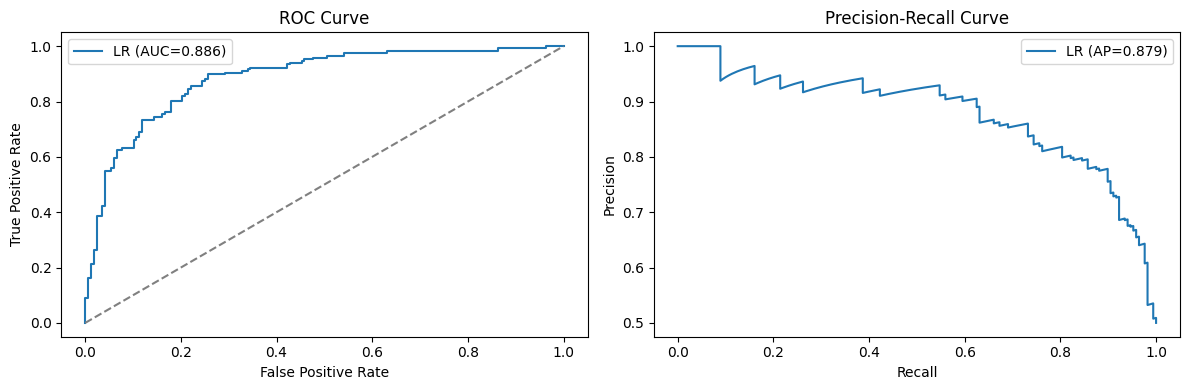

In [76]:
# PR-AUC and curves
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, test_prob)
print(f"PR-AUC (test): {pr_auc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_prob)
axes[0].plot(fpr, tpr, label=f"LR (AUC={roc_auc_score(y_test,test_prob):.3f})")
axes[0].plot([0,1],[0,1],'--',color='gray')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# PR Curve
prec, rec, _ = precision_recall_curve(y_test, test_prob)
axes[1].plot(rec, prec, label=f"LR (AP={pr_auc:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

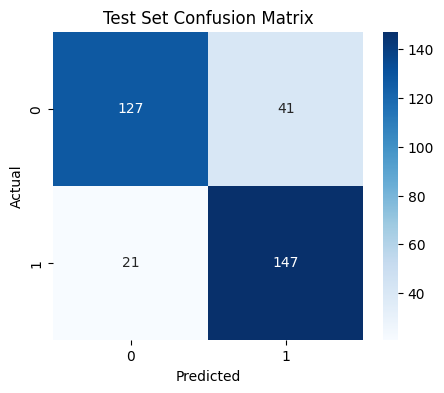

In [77]:
#Confusion matrix
cm = confusion_matrix(y_test,test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

This provides a detailed view of model performance beyond overall accuracy.

- **True Positives (147)**: Customers correctly identified as future churners.
- **True Negatives (127**): Customers correctly identified as non-churners.
- **False Positives (41)**: Customers incorrectly flagged as churn risks.
- **False Negatives (21)**: Customers predicted to stay but who ultimately churned.

From a business perspective, false negatives are more costly because they represent missed opportunities for retention.

At the **selected threshold of 0.40**, the model successfully identified 147 of 168 churning customers while missing only 21 churners, resulting in a recall of 87.5%.(metrix value)



In [78]:
#Extract Metrics for metrics.json
metrics = {"model": "Logistic Regression","threshold": 0.40,
    "accuracy": accuracy_score(y_test,test_pred),
    "precision": precision_score(y_test,test_pred),
    "recall": recall_score(y_test,test_pred),
    "f1_score": f1_score(y_test,test_pred),
    "roc_auc": roc_auc_score(y_test,test_prob),
    "pr_auc": average_precision_score(y_test, test_prob),
    "confusion_matrix": {"tn": int(cm[0,0]),
        "fp": int(cm[0,1]),"fn": int(cm[1,0]),
        "tp": int(cm[1,1])}}
metrics


{'model': 'Logistic Regression',
 'threshold': 0.4,
 'accuracy': 0.8154761904761905,
 'precision': 0.7819148936170213,
 'recall': 0.875,
 'f1_score': 0.8258426966292135,
 'roc_auc': np.float64(0.8855938208616779),
 'pr_auc': np.float64(0.87933115909296),
 'confusion_matrix': {'tn': 127, 'fp': 41, 'fn': 21, 'tp': 147}}

In [79]:
#Save metrics.json
import json
with open("metrics.json","w") as f: json.dump(metrics,f,indent=4)
print("metrics.json saved")

metrics.json saved


In [80]:
#final model
joblib.dump(baseline_model,"model.pkl")
print("model.pkl saved")

model.pkl saved


## Model Persistence

The final Logistic Regression model is saved as `model.pkl` to allow future scoring of customers without retraining the model.

## Final Business Conclusion

The final Logistic Regression model was evaluated on the unseen test dataset using the selected probability threshold of 0.40.

### Test Performance

- Accuracy: 81.5%
- Precision: 78.2%
- Recall: 87.5%
- F1 Score: 82.6%
- ROC-AUC: 0.886


* **Performance:** Strong predictive power with a **87.5% Recall** rate.
* **Value:** Effectively catches the majority of at-risk customers.
* **Strategy:** Minimizes costly False Negatives (missed churners) over cheaper False Positives (unnecessary outreach).


At the selected threshold, the model correctly identified 147 of 168 churning customers while missing only 21 churners.

Although 41 non-churning customers were incorrectly flagged as high risk, the business impact of these false positives is typically lower than the cost of losing a customer without intervention.

These results suggest that the model can be used to support targeted retention campaigns, proactive outreach programs, and customer success initiatives.